#**M2**

## **Part 1: Data Ingestion**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Primary
prim_path = 'gs://wr5477_utds/prim/apple_financial_dataset.csv'
apple_financial = pd.read_csv(prim_path)

# Suppl-1
suppl1_path = 'gs://wr5477_utds/suppl-1/1_apple_news_data.csv'
apple_news = pd.read_csv(suppl1_path)

# Suppl-2 (xlsx)
suppl2_path = 'gs://wr5477_utds/suppl-2/2_Iphone_release_revenue .xlsx'
iphone_release_revenue = pd.read_excel(suppl2_path)

# Suppl-3
suppl3_path = 'gs://wr5477_utds/suppl-3/3_Iphone_marketshare.csv'
iphone_marketshare = pd.read_csv(suppl3_path)

In [ ]:
#Rename columns
apple_financial = apple_financial.rename(columns={"total_volume": "trading_volume","return volatility": "return_volatility"})
apple_news = apple_news.rename(columns={"title": "headline", "link": "source", "content": "summary", "sentiment_polarity": "sentiment_score"})

iphone_release_revenue.columns = iphone_release_revenue.columns.str.lower()
iphone_release_revenue = iphone_release_revenue.rename(columns={"average_selling_price_usd": "average_selling_price", "iphone_model_released": "iphone_model"})

iphone_marketshare.columns = iphone_marketshare.columns.str.lower()
iphone_marketshare = iphone_marketshare.rename(columns={"ios_market_share_precent": "ios_market_share", "android_market_share_percent": "android_market_share"})

## **Part 2: Initial inspection of datasets**

Discover the schema

In [ ]:
apple_financial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fiscal_year        182 non-null    int64  
 1   fiscal_quarter     182 non-null    object 
 2   quarter_start      182 non-null    object 
 3   quarter_end        182 non-null    object 
 4   open_price         182 non-null    float64
 5   close_price        182 non-null    float64
 6   high_price         182 non-null    float64
 7   low_price          182 non-null    float64
 8   trading_volume     182 non-null    int64  
 9   avg_daily_return   182 non-null    float64
 10  return_volatility  182 non-null    float64
 11  quarter_return     182 non-null    float64
 12  avg_volatility     181 non-null    float64
 13  avg_rsi            181 non-null    float64
 14  price_return_pct   182 non-null    float64
dtypes: float64(10), int64(2), object(3)
memory usage: 21.5+ KB


In [ ]:
apple_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29752 entries, 0 to 29751
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             29752 non-null  object 
 1   headline         29752 non-null  object 
 2   summary          29752 non-null  object 
 3   source           29752 non-null  object 
 4   symbols          29752 non-null  object 
 5   tags             17564 non-null  object 
 6   sentiment_score  29737 non-null  float64
 7   sentiment_neg    29737 non-null  float64
 8   sentiment_neu    29737 non-null  float64
 9   sentiment_pos    29737 non-null  float64
dtypes: float64(4), object(6)
memory usage: 2.3+ MB


In [ ]:
iphone_release_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   unnamed: 0                             0 non-null      float64       
 1   year                                   19 non-null     int64         
 2   iphone_model                           19 non-null     object        
 3   release_date                           19 non-null     datetime64[ns]
 4   units_sold_in_year_millions            19 non-null     float64       
 5   average_selling_price                  19 non-null     int64         
 6   annual_iphone_revenue_billions         19 non-null     float64       
 7   annual_total_apple_revenue_billions    19 non-null     float64       
 8   iphone_revenue_as_percentage_of_total  19 non-null     float64       
 9   average_stock_price_usd_annual         19 non-null     float64     

In [ ]:
iphone_marketshare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        13 non-null     int64  
 1   no_of_iphone_users          13 non-null     int64  
 2   no_of_iphone_users_usa      13 non-null     int64  
 3   percentage_of_iphone_users  10 non-null     float64
 4   no_of_iphone_sold           13 non-null     int64  
 5   no_of_iphone_sold_usa       11 non-null     float64
 6   ios_market_share            11 non-null     float64
 7   android_market_share        11 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 964.0 bytes


Display sample records

In [ ]:
apple_financial.head()

,fiscal_year,fiscal_quarter,quarter_start,quarter_end,open_price,close_price,high_price,low_price,trading_volume,avg_daily_return,return_volatility,quarter_return,avg_volatility,avg_rsi,price_return_pct
0,1981,Q1,1980-12-12,1980-12-31,0.098389,0.116784,0.123628,0.086412,1344851200,0.015527,0.049939,0.186321,NaN,NaN,0.186960
1,1981,Q2,1981-01-02,1981-03-31,0.118068,0.083845,0.118923,0.074006,1631324800,-0.004777,0.033508,-0.296170,0.006319,43.700581,-0.289856
2,1981,Q3,1981-04-01,1981-06-30,0.083417,0.088978,0.113790,0.082990,2077913600,0.001384,0.030000,0.087178,0.004790,55.890237,0.066663
3,1981,Q4,1981-07-01,1981-09-30,0.088550,0.052189,0.089834,0.048767,1959731200,-0.007630,0.036474,-0.488336,0.005890,32.904995,-0.410629
4,1982,Q1,1981-10-01,1981-12-31,0.052189,0.075717,0.078712,0.052189,2527974400,0.006340,0.032213,0.405733,0.003602,56.169470,0.450822


In [ ]:
apple_news.head()

,date,headline,summary,source,symbols,tags,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [ ]:
iphone_release_revenue.head()

,unnamed: 0,year,iphone_model,release_date,units_sold_in_year_millions,average_selling_price,annual_iphone_revenue_billions,annual_total_apple_revenue_billions,iphone_revenue_as_percentage_of_total,average_stock_price_usd_annual
0,NaN,2007,iPhone (Original),2007-06-01,1.9,499,0.95,24.58,3.9,4.5
1,NaN,2008,iPhone 3G,2008-07-01,11.6,450,5.22,37.49,13.9,5.1
2,NaN,2009,iPhone 3GS,2009-06-01,20.7,480,9.94,42.91,23.2,6.3
3,NaN,2010,iPhone 4,2010-06-01,39.9,550,21.95,65.23,33.7,9.2
4,NaN,2011,iPhone 4S,2011-10-01,72.3,610,44.10,108.25,40.7,12.5


In [ ]:
iphone_marketshare.head()

,year,no_of_iphone_users,no_of_iphone_users_usa,percentage_of_iphone_users,no_of_iphone_sold,no_of_iphone_sold_usa,ios_market_share,android_market_share
0,2023,1460000000,153000000,58.33,234600000,NaN,58.10,41.46
1,2022,1360000000,149000000,48.70,226400000,124700000.0,56.74,42.94
2,2021,1230000000,141000000,46.90,235700000,116300000.0,58.58,41.11
3,2020,1000000000,138000000,45.30,206100000,113500000.0,59.54,40.20
4,2019,948000000,131000000,45.20,191000000,105200000.0,55.23,44.51


Summarize the central tendency

In [ ]:
apple_financial.describe()

,fiscal_year,open_price,close_price,high_price,low_price,trading_volume,avg_daily_return,return_volatility,quarter_return,avg_volatility,avg_rsi,price_return_pct
count,182.000000,182.000000,182.000000,182.000000,182.000000,1.820000e+02,182.000000,182.000000,182.000000,181.000000,181.000000,182.000000
mean,2003.252747,28.394512,29.782106,32.388749,25.852678,1.932819e+10,0.001106,0.025439,0.067288,0.858855,53.167096,0.072480
std,13.172543,59.289687,61.576475,66.427466,53.944374,1.626458e+10,0.003928,0.010922,0.236249,1.758107,9.426377,0.248746
min,1981.000000,0.043634,0.043634,0.061173,0.037645,7.333521e+08,-0.010246,0.009645,-0.655740,0.002302,18.100366,-0.526853
25%,1992.000000,0.233360,0.240227,0.297168,0.203583,9.080263e+09,-0.001510,0.017224,-0.092139,0.011350,46.299920,-0.105139
50%,2003.000000,0.473577,0.485624,0.594816,0.389773,1.391603e+10,0.001579,0.024087,0.101027,0.046472,54.497614,0.072091
75%,2014.750000,21.469213,22.130185,24.498280,20.387302,2.635507e+10,0.003575,0.031539,0.221242,0.600641,60.022045,0.232267
max,2026.000000,272.260010,271.859985,288.619995,243.763696,8.526002e+10,0.015527,0.077053,0.811956,8.150881,79.869547,1.018348


In [ ]:
apple_news.describe()

,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos
count,29737.000000,29737.000000,29737.000000,29737.000000
mean,0.504849,0.038986,0.863664,0.097352
std,0.578608,0.045621,0.075412,0.068141
min,-1.000000,0.000000,0.238000,0.000000
25%,0.000000,0.000000,0.828000,0.058000
50%,0.778000,0.028000,0.865000,0.094000
75%,0.992000,0.057000,0.904000,0.129000
max,1.000000,0.554000,1.000000,0.762000


In [ ]:
iphone_release_revenue.describe()

,unnamed: 0,year,release_date,units_sold_in_year_millions,average_selling_price,annual_iphone_revenue_billions,annual_total_apple_revenue_billions,iphone_revenue_as_percentage_of_total,average_stock_price_usd_annual
count,0.0,19.000000,19,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,NaN,2016.000000,2016-08-17 00:00:00,157.363158,719.947368,124.634737,220.452632,49.878947,66.663158
min,NaN,2007.000000,2007-06-01 00:00:00,1.900000,450.000000,0.950000,24.580000,3.900000,4.500000
25%,NaN,2011.500000,2012-03-17 00:00:00,98.700000,620.000000,61.455000,132.380000,45.350000,15.000000
50%,NaN,2016.000000,2016-09-01 00:00:00,205.100000,715.000000,159.790000,229.230000,54.700000,30.100000
75%,NaN,2020.500000,2021-03-17 12:00:00,222.400000,845.000000,182.035000,320.170000,61.850000,118.000000
max,NaN,2025.000000,2025-09-01 00:00:00,231.200000,945.000000,218.300000,394.330000,72.300000,210.000000
std,NaN,5.627314,NaN,84.391299,157.169574,75.987538,126.799685,18.863768,71.190497


In [ ]:
iphone_marketshare.describe()

,year,no_of_iphone_users,no_of_iphone_users_usa,percentage_of_iphone_users,no_of_iphone_sold,no_of_iphone_sold_usa,ios_market_share,android_market_share
count,13.00000,1.300000e+01,1.300000e+01,10.00000,1.300000e+01,1.100000e+01,11.000000,11.000000
mean,2017.00000,7.746923e+08,1.100000e+08,46.28300,1.954154e+08,9.145727e+07,55.093636,43.057273
std,3.89444,4.310012e+08,3.705401e+07,4.61565,4.313867e+07,2.514572e+07,2.827707,2.340351
min,2011.00000,1.150000e+08,4.000000e+07,42.30000,9.310000e+07,4.453000e+07,50.850000,39.250000
25%,2014.00000,4.420000e+08,8.800000e+07,43.67500,1.910000e+08,7.740000e+07,52.990000,41.285000
50%,2017.00000,8.140000e+08,1.250000e+08,45.15000,2.088000e+08,9.720000e+07,54.820000,42.940000
75%,2020.00000,1.000000e+09,1.380000e+08,46.50000,2.264000e+08,1.093500e+08,57.420000,44.965000
max,2023.00000,1.460000e+09,1.530000e+08,58.33000,2.357000e+08,1.247000e+08,59.540000,46.420000


## **Part 3: Plot feature distributions**

###Primary Dataset

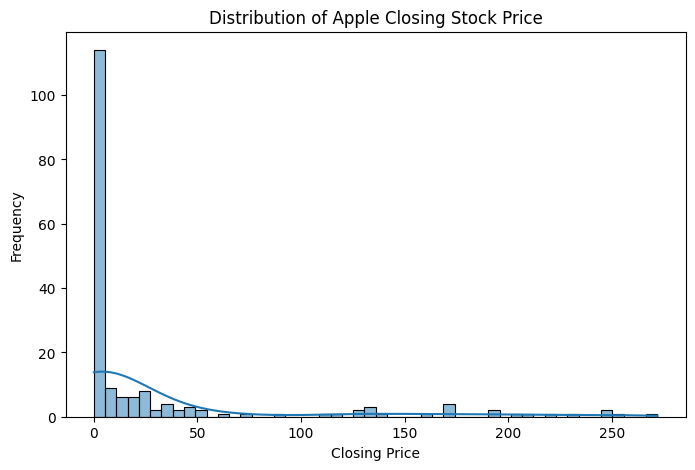

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_financial["close_price"], bins=50, kde=True)
plt.title("Distribution of Apple Closing Stock Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

The closing stock price distribution is strongly right-skewed, with a large concentration of lower price values and a long tail extending toward higher prices. This pattern reflects Apple’s long-term stock price growth over time.

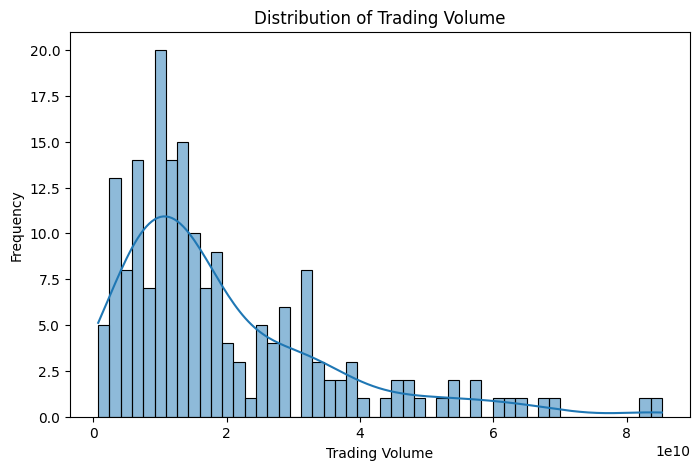

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_financial["trading_volume"], bins=50, kde=True)
plt.title("Distribution of Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")
plt.show()

Trading volume shows a right-skewed distribution with most observations concentrated in lower to moderate trading levels and a few extreme spikes. This suggests occasional periods of heightened investor activity.


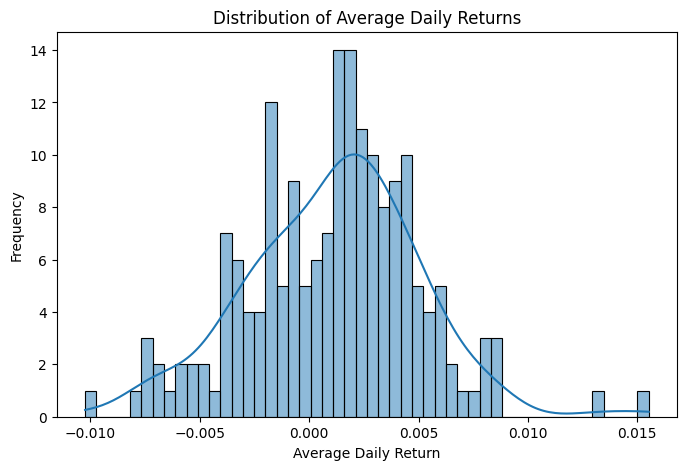

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_financial["avg_daily_return"], bins=50, kde=True)
plt.title("Distribution of Average Daily Returns")
plt.xlabel("Average Daily Return")
plt.ylabel("Frequency")
plt.show()

Average daily returns are centered around zero and display an approximately symmetric distribution, indicating that daily price movements fluctuate between gains and losses, which is typical of stock return behavior.

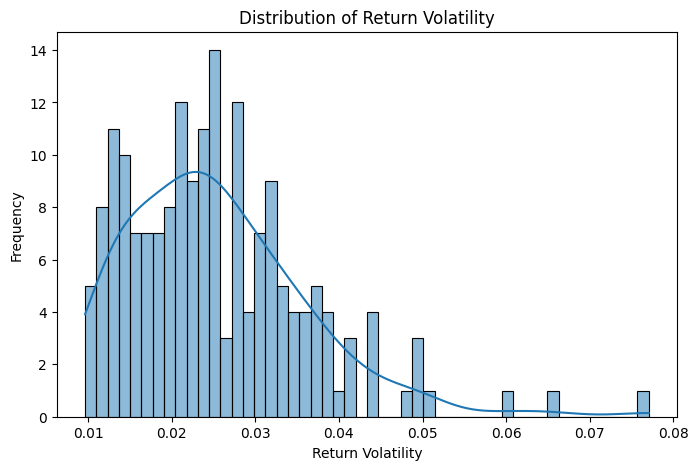

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_financial["return_volatility"], bins=50, kde=True)
plt.title("Distribution of Return Volatility")
plt.xlabel("Return Volatility")
plt.ylabel("Frequency")
plt.show()

Return volatility exhibits a right-skewed distribution, with most observations showing moderate volatility and a smaller number of periods displaying significantly higher volatility levels.

### 1st Supplementary Dataset

In [ ]:
apple_news["date"] = pd.to_datetime(apple_news["date"])

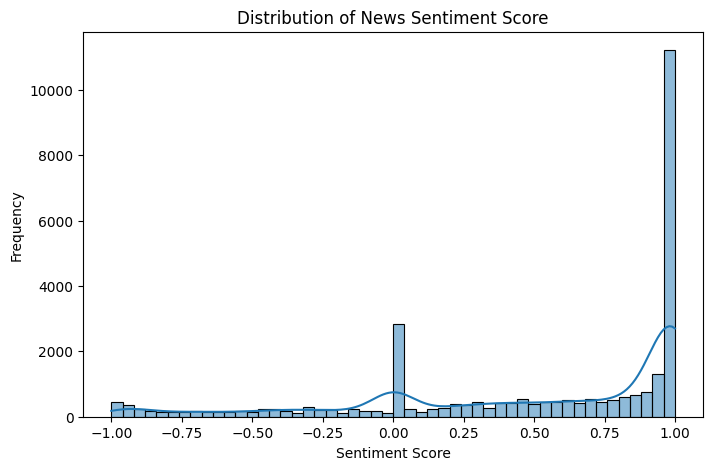

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_news["sentiment_score"], bins=50, kde=True)
plt.title("Distribution of News Sentiment Score")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

The sentiment score distribution is heavily concentrated toward positive values, with a noticeable spike near +1. Most articles appear neutral to positive, suggesting that media coverage of Apple is generally favorable, with fewer strongly negative articles.

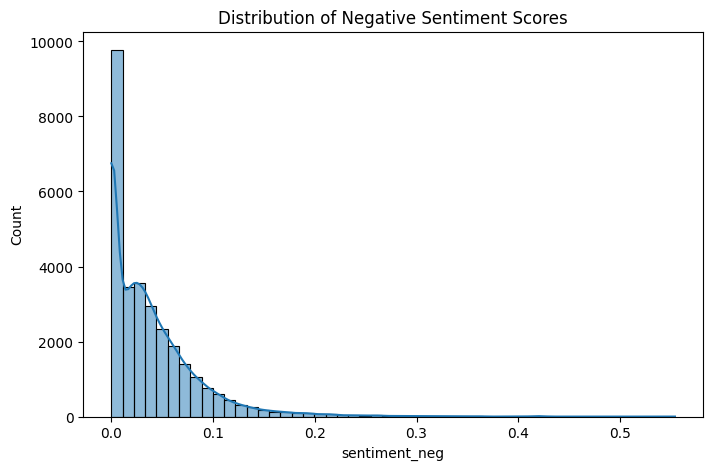

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_news["sentiment_neg"], bins=50, kde=True)
plt.title("Distribution of Negative Sentiment Scores")
plt.show()

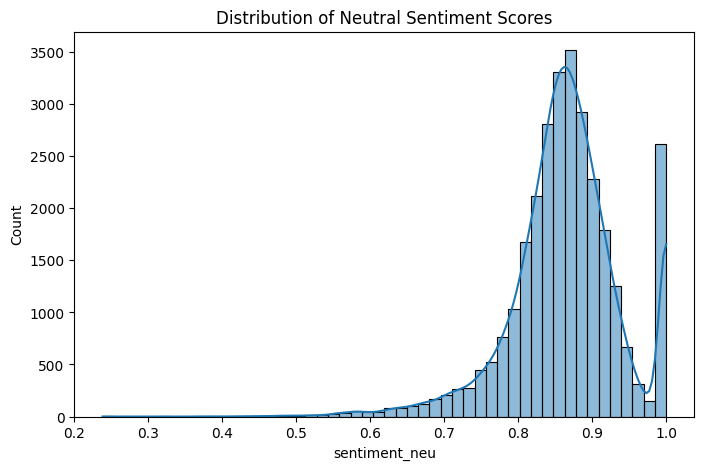

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_news["sentiment_neu"], bins=50, kde=True)
plt.title("Distribution of Neutral Sentiment Scores")
plt.show()

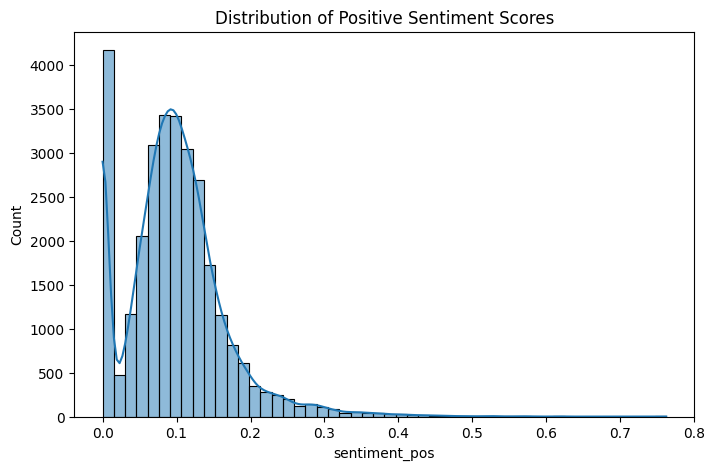

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(apple_news["sentiment_pos"], bins=50, kde=True)
plt.title("Distribution of Positive Sentiment Scores")
plt.show()

Neutral sentiment dominates the dataset, suggesting that most news articles maintain an objective tone. Positive sentiment appears more frequently than negative sentiment, while strongly negative coverage of Apple is relatively rare.

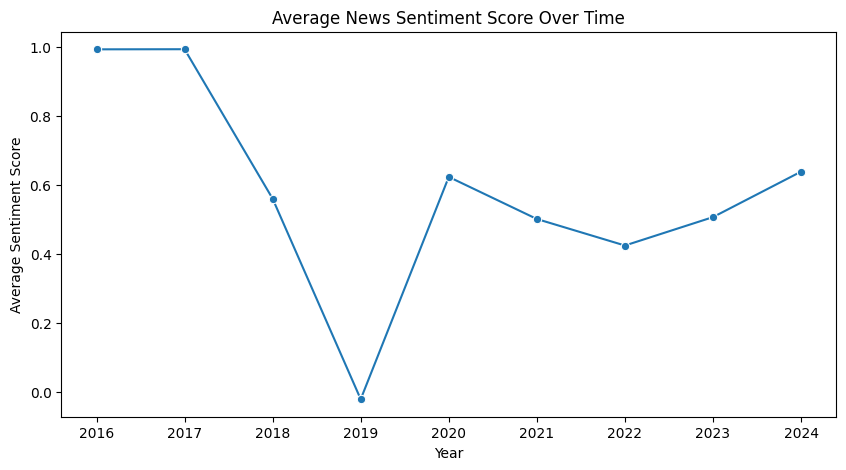

In [ ]:
apple_news["year"] = apple_news["date"].dt.year

yearly_sentiment = apple_news.groupby("year")["sentiment_score"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sentiment, x="year", y="sentiment_score", marker="o")
plt.title("Average News Sentiment Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.show()

Average sentiment scores fluctuate over time but remain mostly within neutral to positive ranges. A noticeable dip appears around 2019, followed by recovery in later years, suggesting variations in public and financial media perception of Apple across different periods.

### 2nd Supplementary Dataset

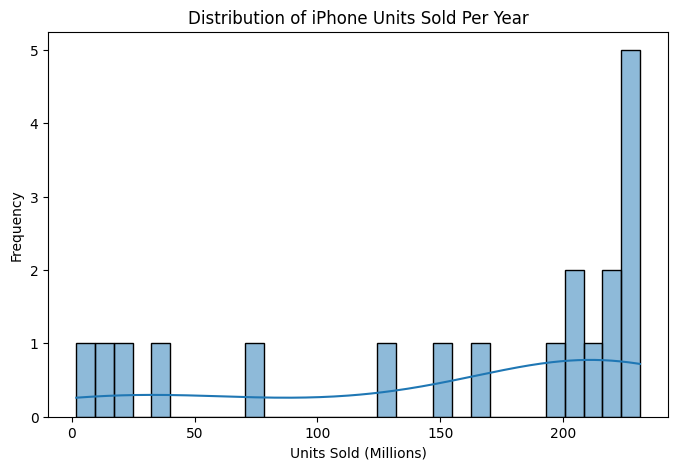

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(iphone_release_revenue["units_sold_in_year_millions"], bins=30, kde=True)
plt.title("Distribution of iPhone Units Sold Per Year")
plt.xlabel("Units Sold (Millions)")
plt.ylabel("Frequency")
plt.show()

The distribution of iPhone units sold is right-skewed, with higher frequencies concentrated at larger sales volumes. This suggests that iPhone sales increased significantly in later years compared to early release periods.



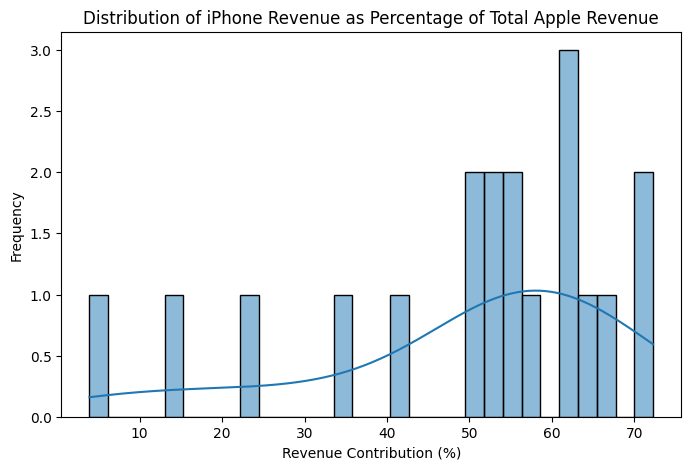

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(iphone_release_revenue["iphone_revenue_as_percentage_of_total"], bins=30, kde=True)
plt.title("Distribution of iPhone Revenue as Percentage of Total Apple Revenue")
plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Frequency")
plt.show()

The percentage of iPhone revenue relative to total Apple revenue is concentrated between approximately 50% and 65%. This indicates that the iPhone consistently represents a major portion of Apple’s overall business performance.



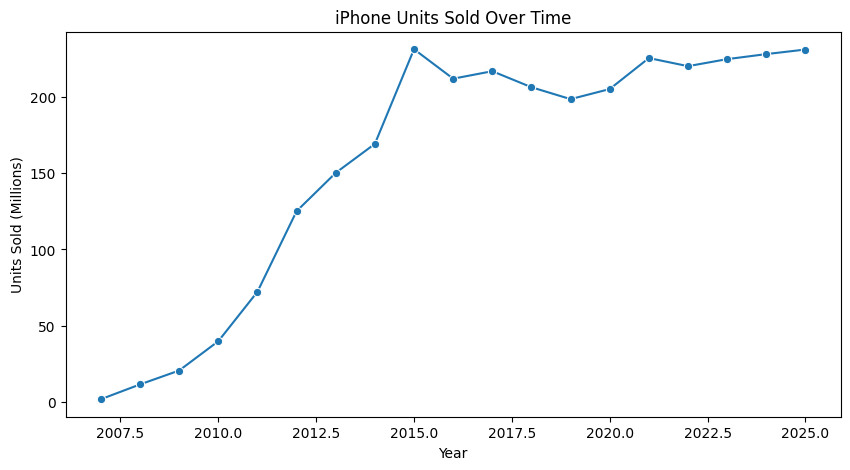

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=iphone_release_revenue, x="year", y="units_sold_in_year_millions", marker="o")
plt.title("iPhone Units Sold Over Time")
plt.xlabel("Year")
plt.ylabel("Units Sold (Millions)")
plt.show()

iPhone unit sales increased rapidly during the early years following the product launch and reached a peak around the mid-2010s. Sales then stabilized with moderate fluctuations in recent years, suggesting market saturation and a mature product lifecycle.



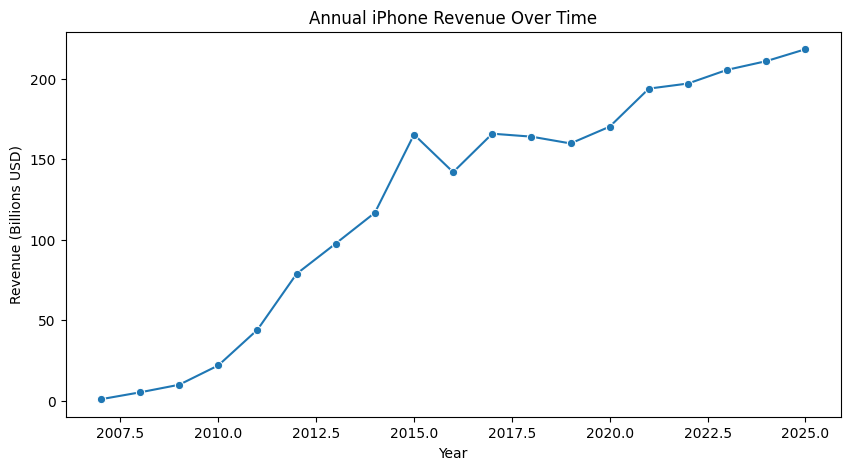

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=iphone_release_revenue, x="year", y="annual_iphone_revenue_billions", marker="o")
plt.title("Annual iPhone Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (Billions USD)")
plt.show()

Annual iPhone revenue shows strong long-term growth with occasional short-term declines. Despite these fluctuations, overall revenue continues to increase, indicating sustained demand and pricing strength in Apple’s smartphone business.



###3rd Supplementary Dataset

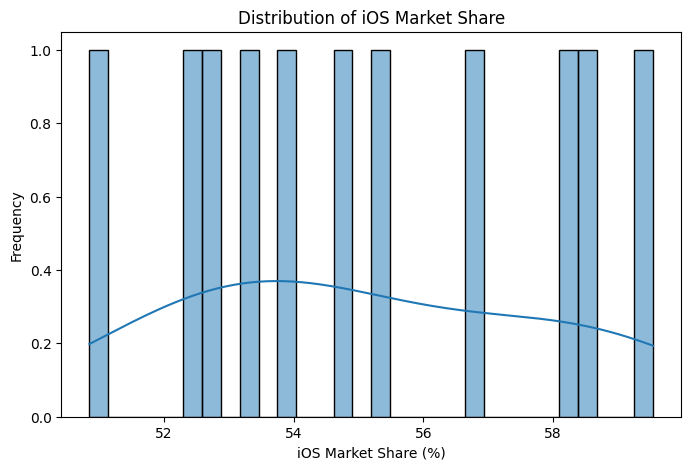

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(iphone_marketshare["ios_market_share"], bins=30, kde=True)
plt.title("Distribution of iOS Market Share")
plt.xlabel("iOS Market Share (%)")
plt.ylabel("Frequency")
plt.show()

The distribution of iOS market share is concentrated within a narrow range between approximately 51% and 59%. This suggests that Apple maintains a relatively stable share of the smartphone market over time.



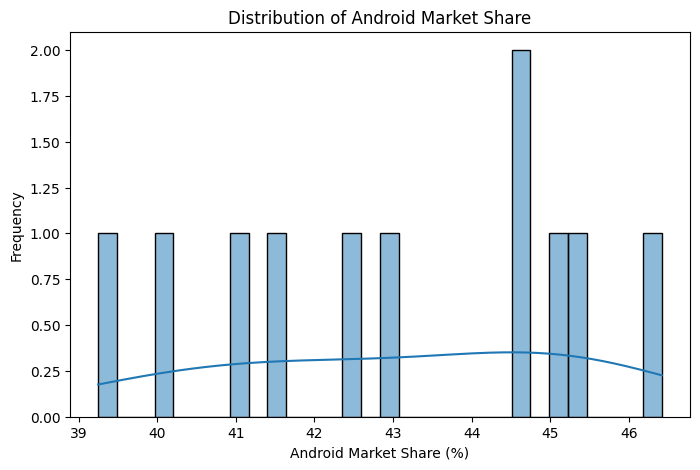

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(iphone_marketshare["android_market_share"], bins=30, kde=True)
plt.title("Distribution of Android Market Share")
plt.xlabel("Android Market Share (%)")
plt.ylabel("Frequency")
plt.show()

Android market share is also distributed within a relatively consistent range but remains slightly lower than iOS in this dataset. The distribution indicates stable competition between the two operating systems.



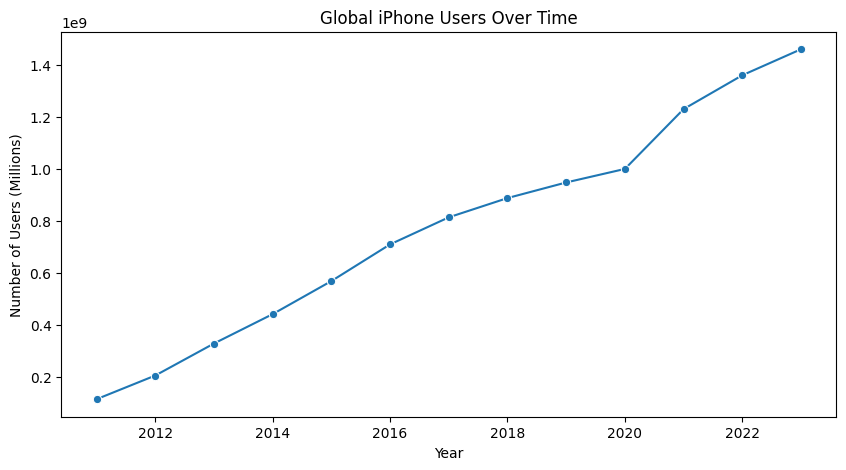

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=iphone_marketshare, x="year", y="no_of_iphone_users", marker="o")
plt.title("Global iPhone Users Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Users (Millions)")
plt.show()

The number of global iPhone users shows steady and continuous growth throughout the observed period. This trend indicates increasing adoption of Apple’s smartphone ecosystem worldwide.



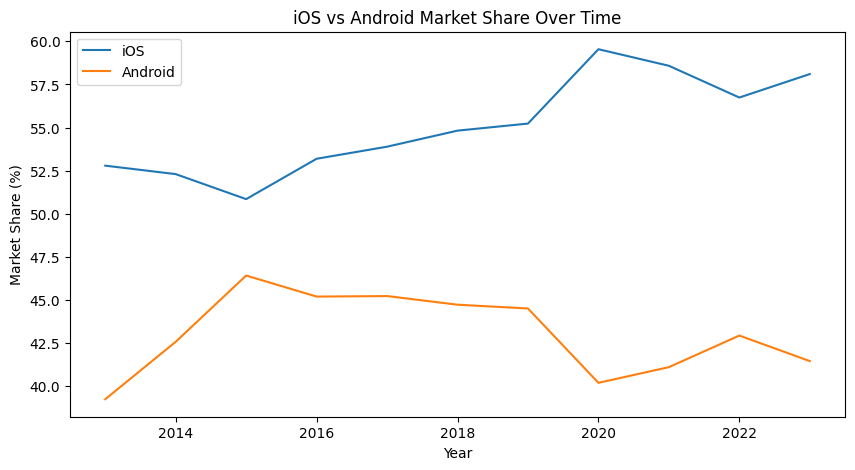

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=iphone_marketshare,
    x="year",
    y="ios_market_share",
    label="iOS"
)

sns.lineplot(
    data=iphone_marketshare,
    x="year",
    y="android_market_share",
    label="Android"
)

plt.title("iOS vs Android Market Share Over Time")
plt.xlabel("Year")
plt.ylabel("Market Share (%)")
plt.legend()
plt.show()


iOS market share generally trends upward over time with moderate fluctuations, while Android market share shows more variation and an overall slightly downward tendency. This pattern highlights the competitive dynamics between the two operating systems and Apple’s strengthening ecosystem presence.



#**M3**

##**Part1 : Data Transformation**

The goal of this project is to analyze how Apple’s financial performance relates to public sentiment and iPhone business trends over time. To support time-series analysis and dataset integration, all datasets must be transformed into consistent and analysis-ready formats.

In this step, I convert date-related fields into proper datetime objects, select features that are directly relevant to the research questions, and re-index each dataset on its primary temporal key (date or year). These transformations enable reliable aggregation, visualization, and merging in later stages of the pipeline.


In [ ]:
import pandas as pd

apple_financial["quarter_end"] = pd.to_datetime(apple_financial["quarter_end"], errors="coerce")
apple_financial["quarter_start"] = pd.to_datetime(apple_financial["quarter_start"], errors="coerce")

apple_news["date"] = pd.to_datetime(apple_news["date"], errors="coerce")

iphone_release_revenue["year"] = iphone_release_revenue["year"].astype(int)
iphone_release_revenue["release_date"] = pd.to_datetime(iphone_release_revenue["release_date"], errors="coerce")

iphone_marketshare["year"] = iphone_marketshare["year"].astype(int)


Date columns were converted using `pd.to_datetime`, which safely handles both string
and datetime inputs. This approach avoids redundant parsing errors and ensures
consistent datetime formatting across datasets.


**Feature Selection**

In [ ]:
financial_features = [
    "quarter_start",
    "quarter_end",
    "open_price",
    "close_price",
    "trading_volume",
    "quarter_return",
    "return_volatility"
]
apple_financial = apple_financial[financial_features]

In [ ]:
news_features = [
    "date",
    "sentiment_score",
    "sentiment_neg",
    "sentiment_neu",
    "sentiment_pos"
]

apple_news = apple_news[news_features]

In [ ]:
revenue_features = [
    "year",
    "release_date",
    "units_sold_in_year_millions",
    "annual_iphone_revenue_billions",
    "iphone_revenue_as_percentage_of_total"
]

iphone_release_revenue = iphone_release_revenue[revenue_features]

In [ ]:
marketshare_features = [
    "year",
    "ios_market_share",
    "android_market_share",
]

iphone_marketshare = iphone_marketshare[marketshare_features]

Feature selection was guided by the research focus on Apple’s financial performance,
public sentiment, and iPhone business indicators. Non-essential metadata and descriptive
fields were removed to reduce redundancy and improve computational efficiency.


**Re-indexing**

In [ ]:
# Time-series indexing
apple_financial = apple_financial.set_index("quarter_end").sort_index()
apple_news = apple_news.set_index("date").sort_index()

# Year-based indexing
iphone_release_revenue = iphone_release_revenue.set_index("year").sort_index()
iphone_marketshare = iphone_marketshare.set_index("year").sort_index()


Each dataset was re-indexed on its primary temporal feature (date or year). This enables
efficient time-based operations, rolling calculations, and alignment across datasets
during aggregation and merging.


##**Part 2: Missing Values and Smoothing**

**Identify missing values**

In [ ]:
# Check missing values in each dataset
missing_summary = {
    "apple_financial": apple_financial.isna().sum(),
    "apple_news": apple_news.isna().sum(),
    "iphone_release_revenue": iphone_release_revenue.isna().sum(),
    "iphone_marketshare": iphone_marketshare.isna().sum()
}

for name, summary in missing_summary.items():
    print(f"\n{name} missing values:")
    display(summary)


apple_financial missing values:


,0
quarter_start,0
open_price,0
close_price,0
trading_volume,0
quarter_return,0
return_volatility,0



apple_news missing values:


,0
sentiment_score,15
sentiment_neg,15
sentiment_neu,15
sentiment_pos,15



iphone_release_revenue missing values:


,0
release_date,0
units_sold_in_year_millions,0
annual_iphone_revenue_billions,0
iphone_revenue_as_percentage_of_total,0



iphone_marketshare missing values:


,0
ios_market_share,2
android_market_share,2


Missing value checks revealed that the primary financial dataset contains no missing
values. The iPhone revenue dataset is also complete. However, the news sentiment dataset
contains 15 missing entries across sentiment-related columns, and the iPhone market
share dataset contains 2 missing values in each platform’s market share column.

Because missing values are limited and occur only in supplementary datasets, targeted
imputation strategies were evaluated rather than applying aggressive cleaning methods.


In [ ]:
iphone_marketshare

,ios_market_share,android_market_share
year,,
2011,NaN,NaN
2012,NaN,NaN
2013,52.79,39.25
2014,52.30,42.58
2015,50.85,46.42
2016,53.19,45.20
2017,53.89,45.23
2018,54.82,44.73
2019,55.23,44.51


In [ ]:
apple_news

,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos
date,,,,
2016-02-19 15:05:00+00:00,0.994,0.023,0.869,0.108
2017-10-05 15:58:00+00:00,0.997,0.008,0.925,0.067
2017-11-27 13:00:00+00:00,0.997,0.008,0.926,0.065
2017-11-30 14:27:00+00:00,0.989,0.021,0.804,0.174
2018-01-31 12:55:00+00:00,0.995,0.009,0.937,0.054
...,...,...,...,...
2024-11-26 00:00:00+00:00,0.000,0.000,1.000,0.000
2024-11-26 00:00:00+00:00,0.000,0.000,1.000,0.000
2024-11-26 00:00:00+00:00,0.000,0.000,1.000,0.000


**Handle missing data**

The datasets used in this project span different temporal ranges and granularities.
The primary Apple financial dataset covers a long daily time horizon (1980–2026),
while the supplementary datasets are more limited in scope. Specifically, the news
sentiment dataset spans 2016–2024, iPhone revenue data spans 2007–2025 at a yearly
granularity, and global smartphone market share data covers 2011–2023.

Because these datasets were not designed to align perfectly in time, missing values
and coverage gaps are expected. Rather than forcing artificial alignment across all
years, missing values were evaluated in context and handled selectively to preserve
analytical validity.


In [ ]:
# Drop early years with no observed market share data
iphone_marketshare_clean = iphone_marketshare.loc[2013:]

The global smartphone market share dataset contains missing values for both iOS and
Android market share in 2011 and 2012. Because these years lack any observed values
across all market share fields, interpolation would require extrapolating beyond the
available data and may introduce bias.

As a result, these early years were removed, and the dataset was truncated to begin
in 2013, the first year with complete observations. This decision prioritizes data
reliability over temporal completeness.


In [ ]:
# Drop minimal missing sentiment rows
apple_news_clean = apple_news.dropna()

The news sentiment dataset contains only 15 missing entries out of over 29,000 rows, representing less than 0.1% of the data. Given the negligible proportion and the large sample size, these rows were dropped without materially impacting the overall sentiment distribution or temporal trends.

**Data smoothing**

After removing the small number of missing observations, all datasets used in this analysis are complete with no remaining null values. However, completeness does not imply smoothness. The daily financial price series and daily news sentiment scores exhibit short-term volatility that can obscure underlying trends. To improve interpretability and highlight longer-term patterns, smoothing techniques were applied in the form of rolling averages. This approach reduces day-to-day noise while preserving meaningful temporal dynamics, making the data more suitable for comparative analysis and aggregation in later stages.

In [ ]:
# 7-day rolling mean smoothing
apple_financial["close_price_smoothed"] = (
    apple_financial["close_price"]
    .rolling(window=7, min_periods=1)
    .mean()
)

apple_news["sentiment_score_smoothed"] = (
    apple_news["sentiment_score"]
    .rolling(window=7, min_periods=1)
    .mean()
)

##**Part3: Aggregation and Joins**

**Aggregate data**

Goal:
- Keep original cleaned datasets (apple_financial, apple_news, iphone_release_revenue, iphone_marketshare) unchanged.
- Create NEW yearly-aggregated and truncated copies for joining.
- Produce one consolidated yearly merged_df for downstream analysis (Q5/Q6).


In [ ]:
# Make SAFE working copies

fin_ts = apple_financial.copy()
news_ts = apple_news.copy()
rev_year = iphone_release_revenue.copy()
ms_year = iphone_marketshare.copy()

In [ ]:
# Aggregate financial data to yearly level
financial_yearly = (
    fin_ts
    .groupby(fin_ts.index.year)
    .agg({
        "close_price": "mean",
        "trading_volume": "sum"
    })
    .rename_axis("year")
    .reset_index()
)

In [ ]:
# Aggregate sentiment data to yearly level
news_yearly = (
    news_ts
    .groupby(news_ts.index.year)
    .agg({
        "sentiment_score": "mean",
        "sentiment_neg": "mean",
        "sentiment_neu": "mean",
        "sentiment_pos": "mean"
    })
    .rename_axis("year")
    .reset_index()
)

Daily financial and sentiment datasets were aggregated to the yearly level to align with the granularity of the iPhone revenue and market share datasets. Mean aggregation was used for price and sentiment variables to capture overall annual trends, while trading volume was summed to reflect total market activity.

**Truncate range**

**Dataset Range**

-Financial: 1980–2026

-News: 2016–2024

-Revenue: 2007–2025

-Market Share: 2013–2023

In [ ]:
START_YEAR = 2016
END_YEAR = 2023

financial_yearly_trunc = financial_yearly.query("year >= @START_YEAR and year <= @END_YEAR").copy()
news_yearly_trunc = news_yearly.query("year >= @START_YEAR and year <= @END_YEAR").copy()
rev_year_trunc = rev_year.query("year >= @START_YEAR and year <= @END_YEAR").copy()
ms_year_trunc = ms_year.query("year >= @START_YEAR and year <= @END_YEAR").copy()


Because the datasets span different time ranges, all datasets were truncated to their
overlapping period from 2016 to 2023. This ensures that all merged observations are
supported by complete information across financial performance, sentiment, revenue,
and market share, avoiding bias introduced by partial coverage.


**Merge All Datasets into One**

In [ ]:
merged_df = (
    financial_yearly_trunc
    .merge(news_yearly_trunc, on="year", how="inner")
    .merge(rev_year_trunc, on="year", how="inner")
    .merge(ms_year_trunc, on="year", how="inner")
)

In [ ]:
print("Original lengths (unchanged):")
print(" apple_financial:", len(apple_financial))
print(" apple_news:", len(apple_news))
print(" iphone_release_revenue:", len(iphone_release_revenue))
print(" iphone_marketshare:", len(iphone_marketshare))

Original lengths (unchanged):
 apple_financial: 182
 apple_news: 29752
 iphone_release_revenue: 19
 iphone_marketshare: 13


In [ ]:
print("\nMerged yearly dataset shape:", merged_df.shape)
display(merged_df.head())


Merged yearly dataset shape: (8, 13)


,year,close_price,trading_volume,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos,release_date,units_sold_in_year_millions,annual_iphone_revenue_billions,iphone_revenue_as_percentage_of_total,ios_market_share,android_market_share
0,2016,24.782260,38729911200,0.994000,0.023000,0.869000,0.108000,2016-09-01,211.9,141.97,65.8,53.19,45.20
1,2017,35.581942,27243106000,0.994333,0.012333,0.885000,0.102000,2017-09-01,216.8,165.85,72.3,53.89,45.23
2,2018,43.529596,34156144800,0.560714,0.045286,0.896571,0.058000,2018-09-01,206.3,164.01,61.7,54.82,44.73
3,2019,54.376593,28254942800,-0.020756,0.080195,0.841683,0.078098,2019-09-01,198.5,159.79,61.4,55.23,44.51
4,2020,97.918919,39863855600,0.624010,0.046225,0.862368,0.091454,2020-10-01,205.1,170.23,62.0,59.54,40.20


All datasets were merged using the year variable as a common key. Inner joins were
applied to ensure that only years with complete data across all sources were retained.
This results in a consolidated dataset suitable for comparative analysis across
financial performance, public sentiment, and iPhone business metrics.


In [ ]:
merged_df.info()
merged_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   year                                   8 non-null      int32         
 1   close_price                            8 non-null      float64       
 2   trading_volume                         8 non-null      int64         
 3   sentiment_score                        8 non-null      float64       
 4   sentiment_neg                          8 non-null      float64       
 5   sentiment_neu                          8 non-null      float64       
 6   sentiment_pos                          8 non-null      float64       
 7   release_date                           8 non-null      datetime64[ns]
 8   units_sold_in_year_millions            8 non-null      float64       
 9   annual_iphone_revenue_billions         8 non-null      float64       

,year,close_price,trading_volume,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos,release_date,units_sold_in_year_millions,annual_iphone_revenue_billions,iphone_revenue_as_percentage_of_total,ios_market_share,android_market_share
count,8.00000,8.000000,8.000000e+00,8.000000,8.000000,8.000000,8.000000,8,8.000000,8.000000,8.000000,8.000000,8.000000
mean,2019.50000,89.806176,2.849144e+10,0.573329,0.040615,0.869154,0.090134,2020-03-05 18:00:00,213.600000,174.773750,59.975000,56.261250,43.172500
min,2016.00000,24.782260,1.480589e+10,-0.020756,0.012333,0.841683,0.058000,2016-09-01 00:00:00,198.500000,141.970000,50.000000,53.190000,40.200000
25%,2017.75000,41.542683,2.262553e+10,0.482692,0.033356,0.862988,0.088115,2018-06-01 18:00:00,206.000000,162.955000,53.450000,54.587500,41.372500
50%,2019.50000,76.147756,2.774902e+10,0.534056,0.040535,0.866660,0.092323,2020-03-17 00:00:00,214.350000,168.040000,61.550000,55.985000,43.725000
75%,2021.25000,141.554997,3.529959e+10,0.716507,0.045521,0.874571,0.099659,2021-12-01 06:00:00,221.250000,194.630000,62.950000,58.220000,44.847500
max,2023.00000,178.613720,3.986386e+10,0.994333,0.080195,0.896571,0.108000,2023-09-01 00:00:00,225.400000,205.500000,72.300000,59.540000,45.230000
std,2.44949,58.468387,8.690734e+09,0.325426,0.019894,0.016328,0.015700,NaN,9.793438,21.772744,7.404005,2.327877,2.022557


##**Part4**

In [ ]:
GCS_BUCKET = "gs://wr5477_utds"
OUTPUT_PATH = f"{GCS_BUCKET}/clean/merged_apple_data.parquet"

merged_df.to_parquet(
    OUTPUT_PATH,
    engine="pyarrow",
    index=False
)

print(f"Saved parquet to: {OUTPUT_PATH}")

Saved parquet to: gs://wr5477_utds/clean/merged_apple_data.parquet


In [ ]:
import pandas as pd

test_df = pd.read_parquet(OUTPUT_PATH)
print("Loaded back from GCS. Shape:", test_df.shape)
test_df.head()

Loaded back from GCS. Shape: (8, 13)


,year,close_price,trading_volume,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos,release_date,units_sold_in_year_millions,annual_iphone_revenue_billions,iphone_revenue_as_percentage_of_total,ios_market_share,android_market_share
0,2016,24.782260,38729911200,0.994000,0.023000,0.869000,0.108000,2016-09-01,211.9,141.97,65.8,53.19,45.20
1,2017,35.581942,27243106000,0.994333,0.012333,0.885000,0.102000,2017-09-01,216.8,165.85,72.3,53.89,45.23
2,2018,43.529596,34156144800,0.560714,0.045286,0.896571,0.058000,2018-09-01,206.3,164.01,61.7,54.82,44.73
3,2019,54.376593,28254942800,-0.020756,0.080195,0.841683,0.078098,2019-09-01,198.5,159.79,61.4,55.23,44.51
4,2020,97.918919,39863855600,0.624010,0.046225,0.862368,0.091454,2020-10-01,205.1,170.23,62.0,59.54,40.20


The final cleaned and merged dataset was saved to GCS in Parquet format under the existing `clean/` directory: `gs://wr5477_utds/clean/merged_apple_data.parquet`. The output URI was printed and the file was read back to verify accessibility for the next stage of the pipeline.

#**M4**

##**Part 1: Map Questions to Visualizations**

Our stock dataset is recorded at the **quarterly level** (quarter start/end, open/close, quarter return, volatility, volume).  
Our news dataset is available at a finer time scale, so we will **aggregate news sentiment to the quarterly level** (e.g., quarterly average sentiment and article counts) to align it with the stock data.


### Q1. Is quarterly news sentiment associated with Apple’s quarterly stock return?

**Proposed Visualizations:**
- Scatterplot: Quarterly Average Sentiment vs Quarterly Return  
- Regression line overlay  
- Dual-line normalized time series (Sentiment vs Return)

**Rationale:**

Daily news sentiment is aggregated to the quarterly level to align with financial data.  
The scatterplot evaluates whether sentiment and returns exhibit a linear association within the same quarter. The regression line and correlation coefficient quantify the strength and direction of this relationship.

The normalized time-series visualization allows us to observe whether peaks and troughs in sentiment align with major return movements across time. This helps distinguish between statistical correlation and visible temporal co-movement.

### Q2. Do extreme quarterly sentiment periods correspond to higher trading volume?

**Proposed Visualizations:**
- Scatterplot: Sentiment vs Quarterly Trading Volume  
- Highlighted extreme sentiment quarters (top/bottom 20%)  
- Dual-line normalized time series (Sentiment vs Volume)

**Rationale:**

Trading volume reflects investor participation and market activity.  
If strong sentiment influences market behavior, we expect elevated volume during sentiment spikes.

The scatterplot evaluates the overall relationship between sentiment and volume.  
Highlighting extreme sentiment quarters isolates high-intensity periods.  
The time-series comparison visually confirms whether trading activity rises during strong sentiment phases.

### Q3. Do sentiment spikes correspond to higher price volatility?

**Proposed Visualizations:**
- Scatterplot: Sentiment vs Same-Quarter Volatility  
- Scatterplot: Sentiment vs Next-Quarter Volatility  
- Dual-line normalized time series (Same-quarter)  
- Dual-line normalized time series (Lag analysis)

**Rationale:**

This question examines both contemporaneous and predictive relationships.

The same-quarter analysis tests whether sentiment and volatility rise together within the same period.  
The lead-lag analysis evaluates whether sentiment spikes precede changes in volatility in the following quarter.

Including both scatterplots and time-series visualizations allows us to distinguish between co-movement, predictive influence, and possible mean-reversion effects.

### Q4. How has Apple’s stock performance evolved over time?

**Proposed Visualizations:**
- Quarterly closing price time series  
- Smoothed trend line (rolling or moving average)

**Rationale:**

A line chart is appropriate for structural time-series analysis.

The raw quarterly closing price captures short-term fluctuations and crisis periods.  
The smoothed trend highlights long-term growth patterns and structural shifts.

This provides context for interpreting sentiment-related and business-structure findings.

### Q5. Is iPhone revenue dependency associated with stock performance?

**Proposed Visualizations:**
- Scatterplot: iPhone Revenue as % of Total Revenue vs Yearly Stock Return  
- Regression line overlay  
- Dual-line normalized yearly time series

**Rationale:**

This analysis evaluates whether Apple’s reliance on iPhone revenue aligns with stock performance.

The scatterplot tests the linear association across yearly observations.  
The time-series visualization highlights structural co-movement during key periods (e.g., expansion around 2020 and contraction in 2022).

This dual approach helps assess both statistical strength and temporal alignment.

### Q6. Does relative iOS market share relate to Apple’s stock performance?

**Proposed Visualizations:**
- Scatterplot: iOS Market Share vs Yearly Stock Return  
- Regression line overlay  
- Dual-line normalized time series

**Rationale:**

Market share represents Apple’s competitive positioning in the global smartphone market.

The scatterplot evaluates cross-sectional association between market dominance and financial returns.  
The time-series visualization reveals structural co-movement during major expansion and contraction phases.

Together, these charts clarify whether competitive strength translates into financial performance alignment.

##**Part 2: Create Visualizations**

In [ ]:
import altair as alt

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

###Q1. Is quarterly news sentiment associated with Apple’s quarterly stock return?

In [ ]:
# 0) Create safe copies so original datasets remain unchanged
fin = apple_financial.copy()
news = apple_news.copy()

In [ ]:
# 1) Prepare Financial Data (Quarterly)

# Reset index to bring quarter_end into a column
fin = fin.reset_index()

# Ensure quarter_end is datetime
fin["quarter_end"] = pd.to_datetime(fin["quarter_end"], errors="coerce")

# Create a quarterly period key (e.g., 2018Q1)
# This avoids mismatches caused by non-standard quarter end dates
fin["q_period"] = fin["quarter_end"].dt.to_period("Q")

# Select relevant financial variables
fin_q = fin[[
    "q_period",
    "quarter_return",
    "trading_volume",
    "return_volatility"
]].copy()

# Rename for clarity
fin_q = fin_q.rename(columns={"quarter_return": "q_return"})

# Drop missing values
fin_q = fin_q.dropna(subset=["q_period", "q_return"])


In [ ]:
# 2) Prepare News Data (Aggregate Daily → Quarterly)
# -------------------------

# Ensure index is datetime
news.index = pd.to_datetime(news.index, errors="coerce")

# If timezone-aware, remove timezone for consistency
if getattr(news.index, "tz", None) is not None:
    news.index = news.index.tz_convert(None)

# Create quarterly period key
news["q_period"] = news.index.to_period("Q")

# Aggregate sentiment metrics to quarterly level
news_q = (
    news.groupby("q_period")
        .agg(
            sentiment_score=("sentiment_score", "mean"),
            sentiment_neg=("sentiment_neg", "mean"),
            sentiment_neu=("sentiment_neu", "mean"),
            sentiment_pos=("sentiment_pos", "mean"),
            news_count=("sentiment_score", "size")
        )
        .reset_index()
)

In [ ]:
# 3) Merge Financial and Sentiment Data

# Merge using quarterly period key
q1_df = fin_q.merge(news_q, on="q_period", how="inner")

# Convert Period to datetime for visualization compatibility
q1_df["quarter_end_date"] = q1_df["q_period"].dt.end_time.dt.normalize()
q1_df["quarter_label"] = q1_df["q_period"].astype(str)

# Drop Period column (Altair cannot serialize Period type)
q1_plot = q1_df.drop(columns=["q_period"], errors="ignore").copy()

# Ensure numeric types
q1_plot["sentiment_score"] = pd.to_numeric(q1_plot["sentiment_score"], errors="coerce")
q1_plot["q_return"] = pd.to_numeric(q1_plot["q_return"], errors="coerce")

# Remove missing values
q1_plot = q1_plot.dropna(subset=["sentiment_score", "q_return"])

print("Q1 merged rows:", len(q1_plot))
q1_plot.head()


Q1 merged rows: 27


,q_return,trading_volume,return_volatility,sentiment_score,sentiment_neg,sentiment_neu,sentiment_pos,news_count,quarter_end_date,quarter_label
0,0.051173,11315040800,0.019033,0.994000,0.023000,0.869000,0.108000,1,2016-03-31,2016Q1
1,0.101026,6544554000,0.011142,0.994333,0.012333,0.885000,0.102000,3,2017-12-31,2017Q4
2,0.004131,9205205600,0.017033,0.580667,0.051333,0.872667,0.075667,3,2018-03-31,2018Q1
3,0.107858,7259020400,0.013385,0.095000,0.073000,0.896000,0.031000,2,2018-06-30,2018Q2
4,-0.333964,10599989600,0.025339,0.996500,0.008500,0.933000,0.058500,2,2018-12-31,2018Q4


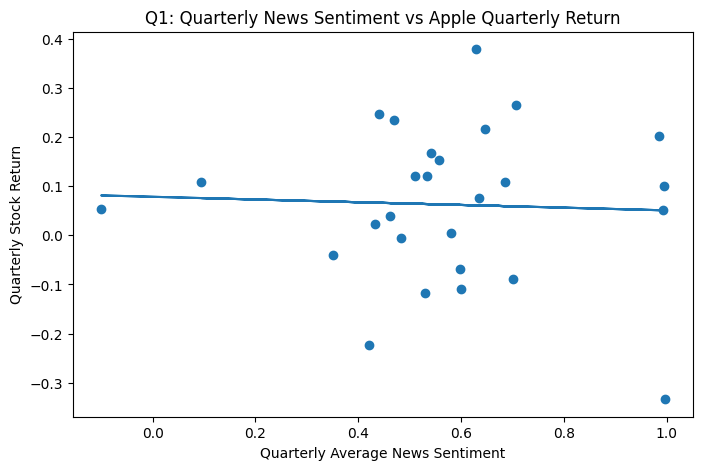

In [ ]:
# Make sure required columns exist
q1_simple = q1_plot.copy()

# Clean numeric
q1_simple["sentiment_score"] = pd.to_numeric(q1_simple["sentiment_score"], errors="coerce")
q1_simple["q_return"] = pd.to_numeric(q1_simple["q_return"], errors="coerce")
q1_simple = q1_simple.dropna(subset=["sentiment_score", "q_return"])

x = q1_simple["sentiment_score"].values
y = q1_simple["q_return"].values

# Create scatter plot
plt.figure(figsize=(8,5))
plt.scatter(x, y)

# Add linear regression line
if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("Quarterly Average News Sentiment")
plt.ylabel("Quarterly Stock Return")
plt.title("Q1: Quarterly News Sentiment vs Apple Quarterly Return")
plt.show()

In [ ]:
corr = q1_simple["sentiment_score"].corr(q1_simple["q_return"])
print("Correlation:", round(corr, 3))

Correlation: -0.044


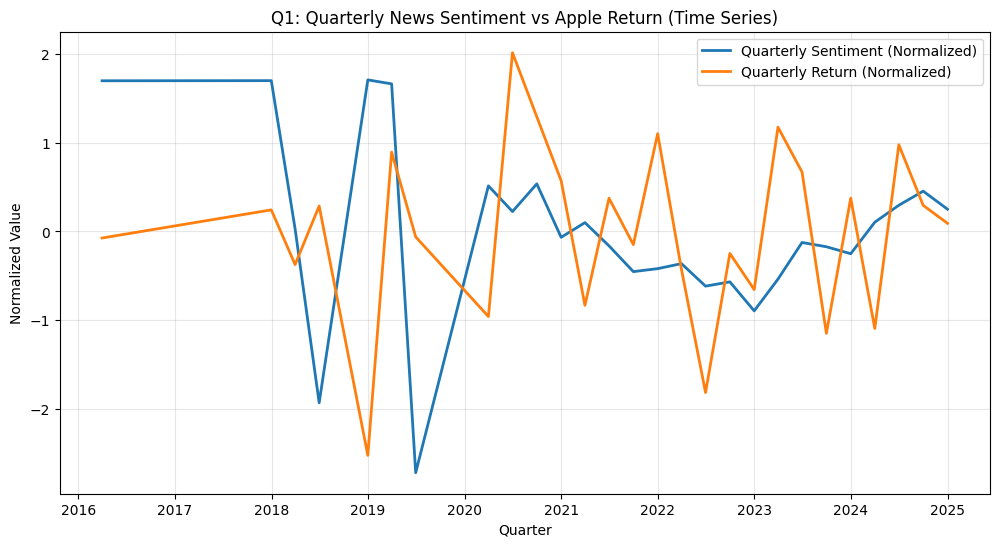

In [ ]:
# Prepare data
viz_q1 = q1_plot.copy()
viz_q1 = viz_q1.sort_values("quarter_end_date")

# Normalize both series for better visual comparison (optional but recommended)
viz_q1["sentiment_norm"] = (
    viz_q1["sentiment_score"] - viz_q1["sentiment_score"].mean()
) / viz_q1["sentiment_score"].std()

viz_q1["return_norm"] = (
    viz_q1["q_return"] - viz_q1["q_return"].mean()
) / viz_q1["q_return"].std()

# Plot
plt.figure(figsize=(12,6))

plt.plot(viz_q1["quarter_end_date"],
         viz_q1["sentiment_norm"],
         label="Quarterly Sentiment (Normalized)",
         linewidth=2)

plt.plot(viz_q1["quarter_end_date"],
         viz_q1["return_norm"],
         label="Quarterly Return (Normalized)",
         linewidth=2)

plt.title("Q1: Quarterly News Sentiment vs Apple Return (Time Series)")
plt.xlabel("Quarter")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Daily news sentiment was aggregated into quarterly averages and aligned with Apple's quarterly stock returns.

The scatterplot indicates a very weak linear relationship between sentiment and stock returns, with a correlation coefficient of approximately -0.044. The regression line is nearly flat, suggesting little to no linear association.

To further explore temporal dynamics, we visualized both variables as normalized time series. While some quarters show coinciding movements, the overall patterns do not consistently move together over time. Peaks and troughs in sentiment do not systematically align with large movements in stock returns.

Taken together, both the cross-sectional and time-series analyses suggest that quarterly news sentiment does not meaningfully explain variations in Apple’s quarterly stock returns. Any observed relationship appears weak and likely not statistically significant.

###Q2. Do extreme sentiment quarters correspond to higher trading volume?

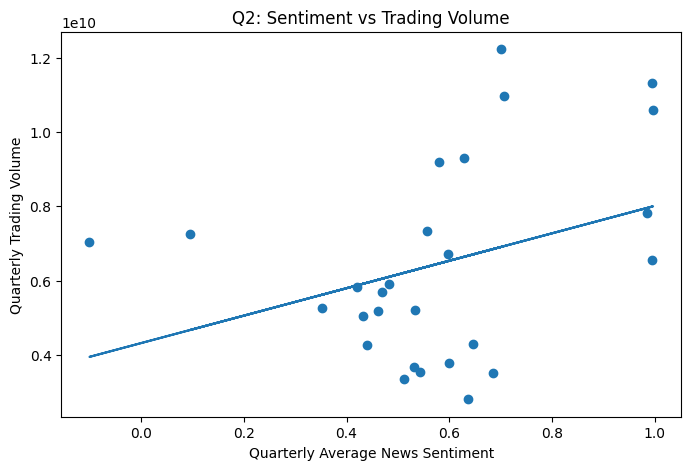

In [ ]:
# Prepare data
q2_df = q1_plot.copy()

# Ensure numeric
q2_df["sentiment_score"] = pd.to_numeric(q2_df["sentiment_score"], errors="coerce")
q2_df["trading_volume"] = pd.to_numeric(q2_df["trading_volume"], errors="coerce")

q2_df = q2_df.dropna(subset=["sentiment_score", "trading_volume"])

x = q2_df["sentiment_score"].values
y = q2_df["trading_volume"].values

# Plot
plt.figure(figsize=(8,5))
plt.scatter(x, y)

# Regression line
if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("Quarterly Average News Sentiment")
plt.ylabel("Quarterly Trading Volume")
plt.title("Q2: Sentiment vs Trading Volume")
plt.show()

In [ ]:
corr_q2 = q2_df["sentiment_score"].corr(q2_df["trading_volume"])
print("Correlation:", round(corr_q2, 3))

Correlation: 0.342


In [ ]:
# Define extreme sentiment (top/bottom 20%)
lower = q2_df["sentiment_score"].quantile(0.2)
upper = q2_df["sentiment_score"].quantile(0.8)

extreme = q2_df[(q2_df["sentiment_score"] <= lower) |
                (q2_df["sentiment_score"] >= upper)]

print("Average volume (all):", round(q2_df["trading_volume"].mean(), 2))
print("Average volume (extreme sentiment):", round(extreme["trading_volume"].mean(), 2))

Average volume (all): 6433769688.89
Average volume (extreme sentiment): 7849782158.33


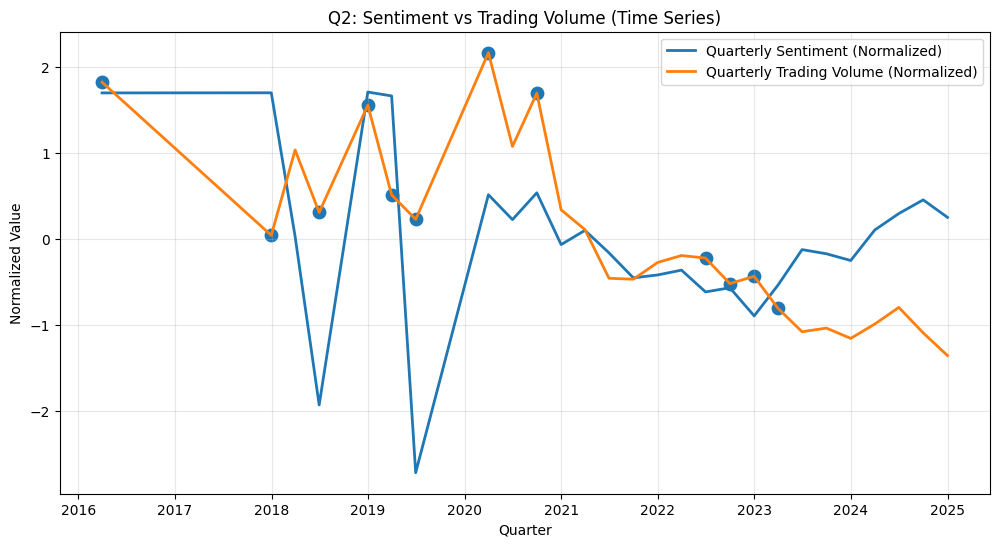

In [ ]:
viz_q2 = q1_plot.copy()
viz_q2 = viz_q2.sort_values("quarter_end_date")

# Normalize both series for visual comparability
viz_q2["sentiment_norm"] = (
    viz_q2["sentiment_score"] - viz_q2["sentiment_score"].mean()
) / viz_q2["sentiment_score"].std()

viz_q2["volume_norm"] = (
    viz_q2["trading_volume"] - viz_q2["trading_volume"].mean()
) / viz_q2["trading_volume"].std()

plt.figure(figsize=(12,6))

plt.plot(viz_q2["quarter_end_date"],
         viz_q2["sentiment_norm"],
         label="Quarterly Sentiment (Normalized)",
         linewidth=2)

plt.plot(viz_q2["quarter_end_date"],
         viz_q2["volume_norm"],
         label="Quarterly Trading Volume (Normalized)",
         linewidth=2)

# Highlight extreme sentiment quarters
lower = viz_q2["sentiment_score"].quantile(0.2)
upper = viz_q2["sentiment_score"].quantile(0.8)

extreme = viz_q2[(viz_q2["sentiment_score"] <= lower) |
                 (viz_q2["sentiment_score"] >= upper)]

plt.scatter(extreme["quarter_end_date"],
            extreme["volume_norm"],
            s=80)

plt.title("Q2: Sentiment vs Trading Volume (Time Series)")
plt.xlabel("Quarter")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We examined whether quarters with unusually high or low news sentiment were associated with increased trading activity.

The scatterplot shows a positive relationship between sentiment and trading volume, with a correlation coefficient of approximately 0.342, indicating a moderate positive association.

Additionally, quarters with extreme sentiment (top and bottom 20%) had a higher average trading volume (≈ 7.85B) compared to the overall quarterly average (≈ 6.43B).

To further explore temporal dynamics, we visualized sentiment and trading volume as normalized time series. The chart shows that several sentiment spikes coincide with elevated trading volume levels. Periods of unusually strong positive or negative sentiment tend to align with increases in market activity.

Together, the cross-sectional and time-series analyses suggest that stronger sentiment—whether positive or negative—is associated with increased investor participation and trading intensity.

###Q3. Do sentiment spikes precede higher price volatility?

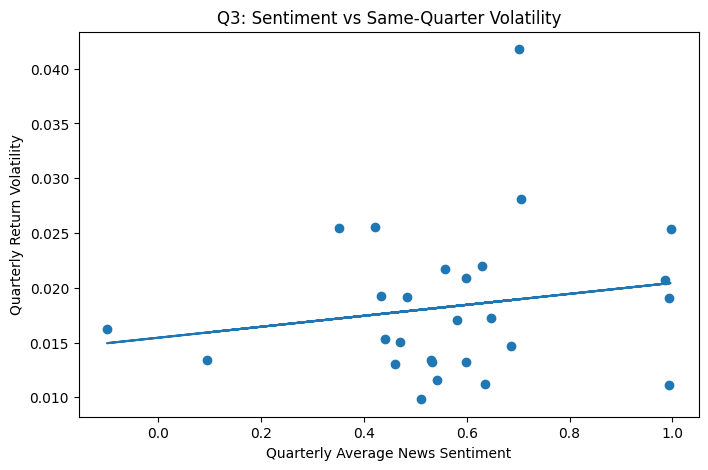

In [ ]:
# Prepare data
q3_df = q1_plot.copy()

# Ensure numeric
q3_df["sentiment_score"] = pd.to_numeric(q3_df["sentiment_score"], errors="coerce")
q3_df["return_volatility"] = pd.to_numeric(q3_df["return_volatility"], errors="coerce")

q3_df = q3_df.dropna(subset=["sentiment_score", "return_volatility"])

x = q3_df["sentiment_score"].values
y = q3_df["return_volatility"].values

plt.figure(figsize=(8,5))
plt.scatter(x, y)

# Regression line
if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("Quarterly Average News Sentiment")
plt.ylabel("Quarterly Return Volatility")
plt.title("Q3: Sentiment vs Same-Quarter Volatility")
plt.show()

In [ ]:
corr_q3 = q3_df["sentiment_score"].corr(q3_df["return_volatility"])
print("Same-quarter correlation:", round(corr_q3, 3))

Same-quarter correlation: 0.18


In [ ]:
# Sort chronologically
q3_df = q3_df.sort_values("quarter_end_date")

# Create next-quarter volatility column
q3_df["next_volatility"] = q3_df["return_volatility"].shift(-1)

lead_df = q3_df.dropna(subset=["sentiment_score", "next_volatility"])

lead_corr = lead_df["sentiment_score"].corr(lead_df["next_volatility"])

print("Lead correlation (Sentiment → Next Quarter Volatility):", round(lead_corr, 3))

Lead correlation (Sentiment → Next Quarter Volatility): -0.483


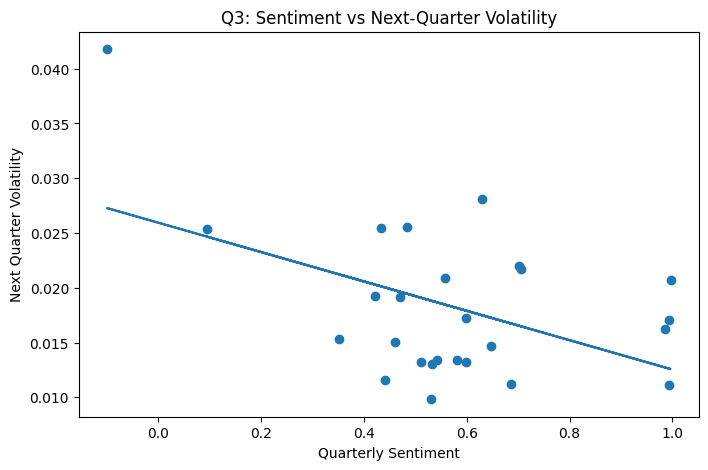

In [ ]:
x = lead_df["sentiment_score"].values
y = lead_df["next_volatility"].values

plt.figure(figsize=(8,5))
plt.scatter(x, y)

if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("Quarterly Sentiment")
plt.ylabel("Next Quarter Volatility")
plt.title("Q3: Sentiment vs Next-Quarter Volatility")
plt.show()

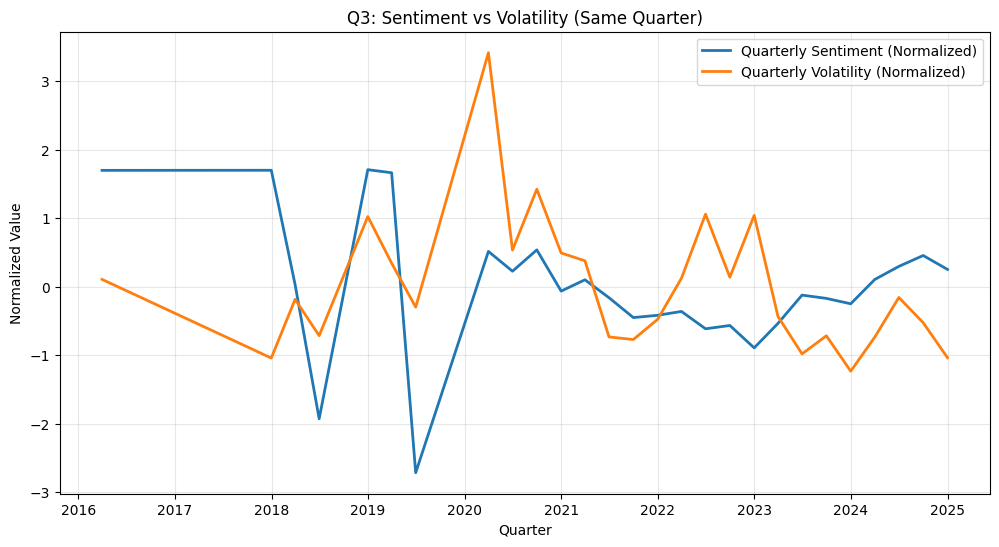

In [ ]:
viz_q3 = q1_plot.copy()
viz_q3 = viz_q3.sort_values("quarter_end_date")

# Normalize
viz_q3["sentiment_norm"] = (
    viz_q3["sentiment_score"] - viz_q3["sentiment_score"].mean()
) / viz_q3["sentiment_score"].std()

viz_q3["vol_norm"] = (
    viz_q3["return_volatility"] - viz_q3["return_volatility"].mean()
) / viz_q3["return_volatility"].std()

plt.figure(figsize=(12,6))

plt.plot(viz_q3["quarter_end_date"],
         viz_q3["sentiment_norm"],
         label="Quarterly Sentiment (Normalized)",
         linewidth=2)

plt.plot(viz_q3["quarter_end_date"],
         viz_q3["vol_norm"],
         label="Quarterly Volatility (Normalized)",
         linewidth=2)

plt.title("Q3: Sentiment vs Volatility (Same Quarter)")
plt.xlabel("Quarter")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

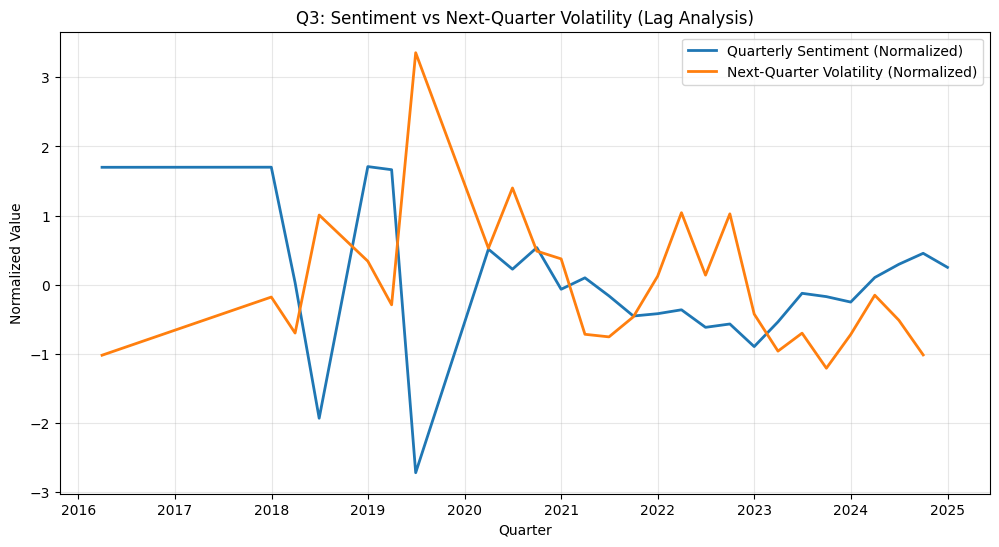

In [ ]:
viz_q3 = viz_q3.sort_values("quarter_end_date")

# Create next-quarter volatility
viz_q3["next_volatility"] = viz_q3["return_volatility"].shift(-1)

# Normalize next-quarter volatility
viz_q3["next_vol_norm"] = (
    viz_q3["next_volatility"] - viz_q3["next_volatility"].mean()
) / viz_q3["next_volatility"].std()

plt.figure(figsize=(12,6))

plt.plot(viz_q3["quarter_end_date"],
         viz_q3["sentiment_norm"],
         label="Quarterly Sentiment (Normalized)",
         linewidth=2)

plt.plot(viz_q3["quarter_end_date"],
         viz_q3["next_vol_norm"],
         label="Next-Quarter Volatility (Normalized)",
         linewidth=2)

plt.title("Q3: Sentiment vs Next-Quarter Volatility (Lag Analysis)")
plt.xlabel("Quarter")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We examined the relationship between quarterly news sentiment and return volatility, both within the same quarter and in the following quarter.

The same-quarter correlation between sentiment and volatility is approximately 0.18, indicating a weak positive association. The time-series visualization also shows that several sentiment fluctuations tend to move in the same general direction as volatility within the same quarter, suggesting limited but observable contemporaneous alignment.

In contrast, the one-quarter lead analysis yields a correlation of approximately -0.483. This moderate negative correlation suggests that higher sentiment is followed by lower volatility in the subsequent quarter. The lagged time-series plot visually reinforces this pattern, as periods of elevated sentiment often precede relatively calmer market conditions.

Overall, the results indicate that sentiment aligns more closely with volatility within the same quarter than it does in predicting future volatility. Rather than causing increased instability, stronger sentiment appears to be associated with more stable market conditions in the following quarter.

###Q4. How has Apple’s stock price evolved over time?

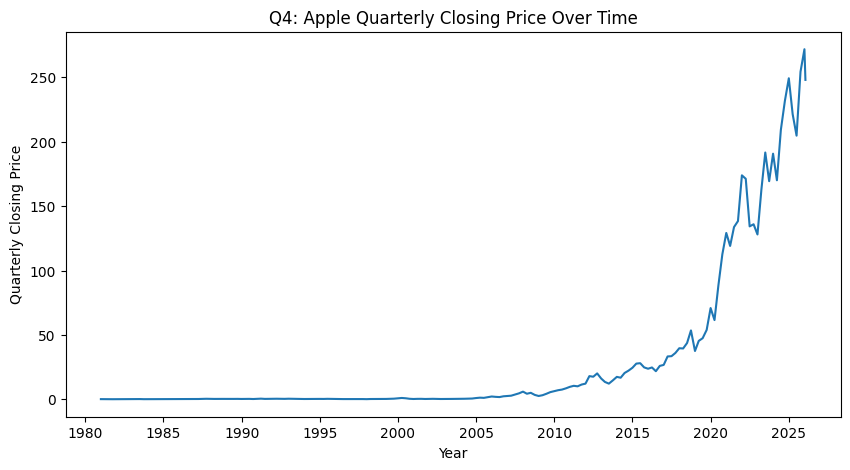

In [ ]:
# Prepare financial time series
q4_df = apple_financial.copy()

# Ensure index is datetime
q4_df = q4_df.reset_index()
q4_df["quarter_end"] = pd.to_datetime(q4_df["quarter_end"], errors="coerce")

# Sort chronologically
q4_df = q4_df.sort_values("quarter_end")

plt.figure(figsize=(10,5))
plt.plot(q4_df["quarter_end"], q4_df["close_price"])

plt.xlabel("Year")
plt.ylabel("Quarterly Closing Price")
plt.title("Q4: Apple Quarterly Closing Price Over Time")
plt.show()

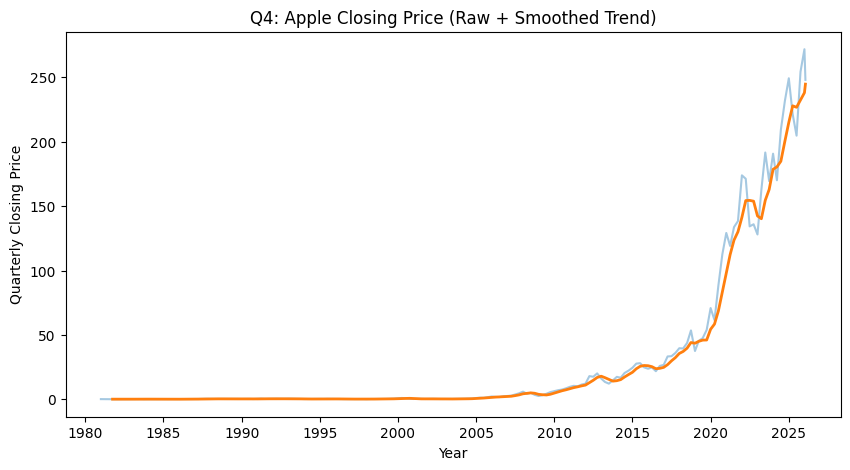

In [ ]:
# Add rolling mean for smoother trend
q4_df["smoothed_price"] = q4_df["close_price"].rolling(window=4).mean()

plt.figure(figsize=(10,5))
plt.plot(q4_df["quarter_end"], q4_df["close_price"], alpha=0.4)
plt.plot(q4_df["quarter_end"], q4_df["smoothed_price"], linewidth=2)

plt.xlabel("Year")
plt.ylabel("Quarterly Closing Price")
plt.title("Q4: Apple Closing Price (Raw + Smoothed Trend)")
plt.show()

We visualized Apple’s quarterly closing price to examine its long-term trajectory.

The time-series chart shows minimal growth from 1980 to the early 2000s. However, beginning around 2007—coinciding with the introduction of the iPhone—the stock price began a strong upward trend.

Although short-term fluctuations occurred during events such as the 2008 financial crisis and the COVID-19 pandemic, the smoothed trend confirms sustained structural growth over the long run.

Overall, Apple’s stock performance demonstrates significant long-term appreciation despite periodic volatility.

###Q5. Is iPhone revenue dependency associated with stock performance?

In [ ]:
# Use merged yearly dataset
q5_df = merged_df.copy()

# If yearly return not already calculated, compute it
if "yearly_return" not in q5_df.columns:
    q5_df = q5_df.sort_values("year")
    q5_df["yearly_return"] = q5_df["close_price"].pct_change()

# Clean
q5_df["iphone_revenue_as_percentage_of_total"] = pd.to_numeric(
    q5_df["iphone_revenue_as_percentage_of_total"], errors="coerce"
)
q5_df["yearly_return"] = pd.to_numeric(q5_df["yearly_return"], errors="coerce")

q5_df = q5_df.dropna(subset=[
    "iphone_revenue_as_percentage_of_total",
    "yearly_return"
])

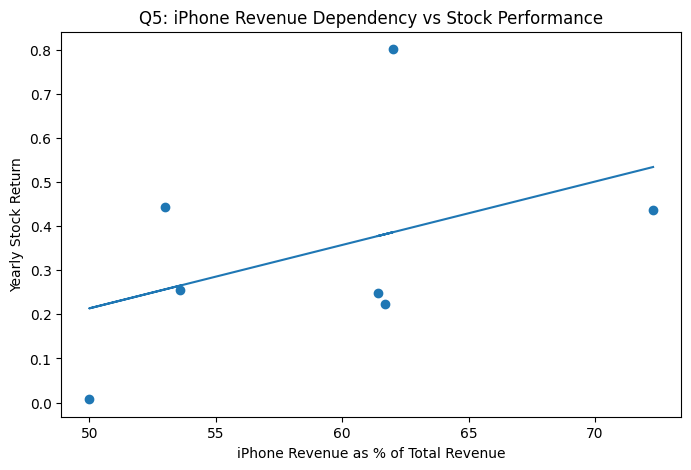

In [ ]:
x = q5_df["iphone_revenue_as_percentage_of_total"].values
y = q5_df["yearly_return"].values

plt.figure(figsize=(8,5))
plt.scatter(x, y)

if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("iPhone Revenue as % of Total Revenue")
plt.ylabel("Yearly Stock Return")
plt.title("Q5: iPhone Revenue Dependency vs Stock Performance")
plt.show()

In [ ]:
corr_q5 = q5_df["iphone_revenue_as_percentage_of_total"].corr(q5_df["yearly_return"])
print("Correlation:", round(corr_q5, 3))

Correlation: 0.438


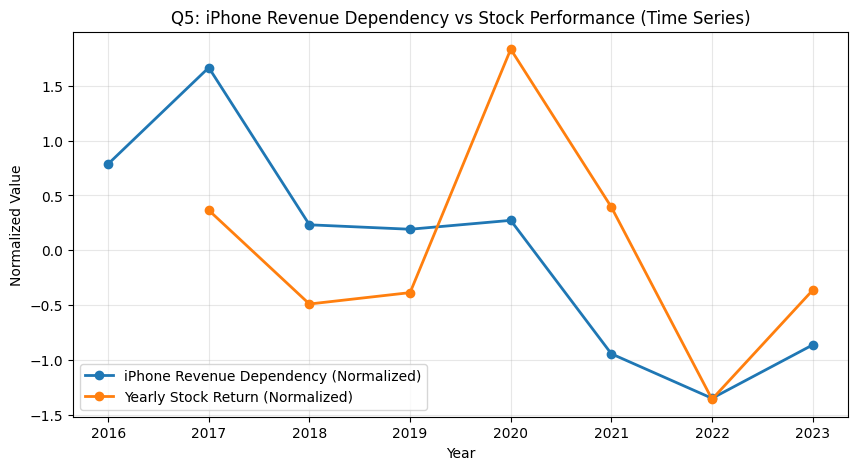

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

viz_q5 = merged_df.copy()
viz_q5 = viz_q5.sort_values("year")

# Make sure yearly return exists
if "yearly_return" not in viz_q5.columns:
    viz_q5["yearly_return"] = viz_q5["close_price"].pct_change()

# Normalize for visual comparison
viz_q5["rev_dep_norm"] = (
    viz_q5["iphone_revenue_as_percentage_of_total"] -
    viz_q5["iphone_revenue_as_percentage_of_total"].mean()
) / viz_q5["iphone_revenue_as_percentage_of_total"].std()

viz_q5["return_norm"] = (
    viz_q5["yearly_return"] -
    viz_q5["yearly_return"].mean()
) / viz_q5["yearly_return"].std()

plt.figure(figsize=(10,5))

plt.plot(viz_q5["year"],
         viz_q5["rev_dep_norm"],
         marker="o",
         linewidth=2,
         label="iPhone Revenue Dependency (Normalized)")

plt.plot(viz_q5["year"],
         viz_q5["return_norm"],
         marker="o",
         linewidth=2,
         label="Yearly Stock Return (Normalized)")

plt.title("Q5: iPhone Revenue Dependency vs Stock Performance (Time Series)")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We examined whether Apple’s dependency on iPhone revenue (measured as the percentage of total revenue) is associated with yearly stock returns.

The scatterplot and correlation analysis show a correlation of approximately 0.438, indicating a moderate positive association.

The time-series visualization further reinforces this relationship. Several key movements align closely across years. For example, both revenue dependency and stock returns increase around 2017, peak around 2020, decline in 2022, and partially recover in 2023. This temporal co-movement suggests that periods of stronger reliance on iPhone revenue tend to coincide with stronger stock performance.

Overall, the evidence indicates that iPhone revenue concentration remains an important structural driver of investor expectations and valuation during the observed period.

However, given the limited number of yearly observations, the findings should be interpreted cautiously and do not imply causation.

###Q6. Does relative iOS market share (vs Android) relate to Apple’s stock performance?


In [ ]:
q6_df = merged_df.copy()

# Ensure yearly return exists
if "yearly_return" not in q6_df.columns:
    q6_df = q6_df.sort_values("year")
    q6_df["yearly_return"] = q6_df["close_price"].pct_change()

# Clean numeric
q6_df["ios_market_share"] = pd.to_numeric(q6_df["ios_market_share"], errors="coerce")
q6_df["yearly_return"] = pd.to_numeric(q6_df["yearly_return"], errors="coerce")

q6_df = q6_df.dropna(subset=["ios_market_share", "yearly_return"])

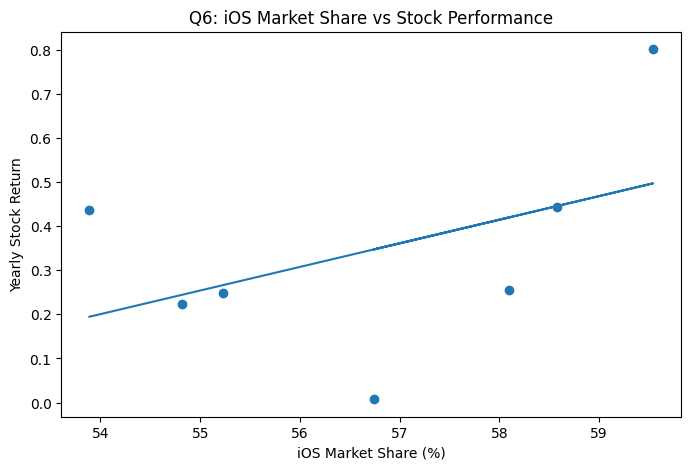

In [ ]:
x = q6_df["ios_market_share"].values
y = q6_df["yearly_return"].values

plt.figure(figsize=(8,5))
plt.scatter(x, y)

if len(x) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)

plt.xlabel("iOS Market Share (%)")
plt.ylabel("Yearly Stock Return")
plt.title("Q6: iOS Market Share vs Stock Performance")
plt.show()

In [ ]:
corr_q6 = q6_df["ios_market_share"].corr(q6_df["yearly_return"])
print("Correlation:", round(corr_q6, 3))

Correlation: 0.457


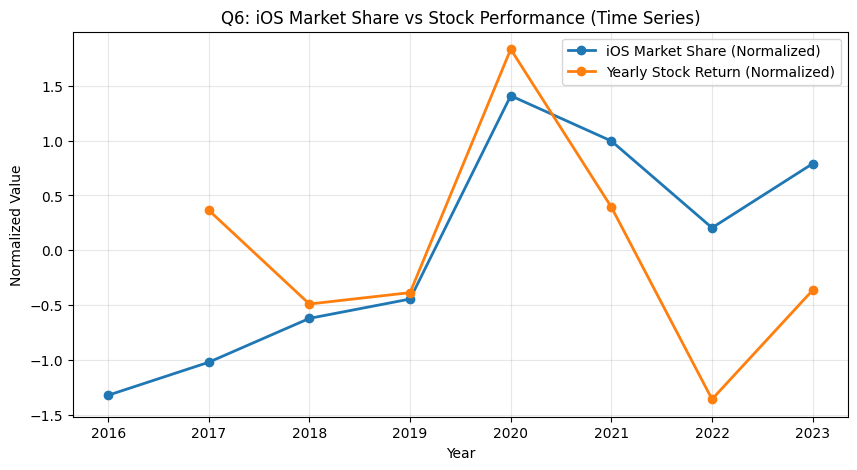

In [ ]:
viz_q6 = merged_df.copy()
viz_q6 = viz_q6.sort_values("year")

# Ensure yearly return exists
if "yearly_return" not in viz_q6.columns:
    viz_q6["yearly_return"] = viz_q6["close_price"].pct_change()

# Normalize for comparability
viz_q6["share_norm"] = (
    viz_q6["ios_market_share"] -
    viz_q6["ios_market_share"].mean()
) / viz_q6["ios_market_share"].std()

viz_q6["return_norm"] = (
    viz_q6["yearly_return"] -
    viz_q6["yearly_return"].mean()
) / viz_q6["yearly_return"].std()

plt.figure(figsize=(10,5))

plt.plot(viz_q6["year"],
         viz_q6["share_norm"],
         marker="o",
         linewidth=2,
         label="iOS Market Share (Normalized)")

plt.plot(viz_q6["year"],
         viz_q6["return_norm"],
         marker="o",
         linewidth=2,
         label="Yearly Stock Return (Normalized)")

plt.title("Q6: iOS Market Share vs Stock Performance (Time Series)")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We examined whether Apple’s global iOS market share is associated with yearly stock returns.

The scatterplot indicates a moderate positive relationship (correlation ≈ 0.457), suggesting that higher market share generally coincides with stronger stock performance.

The time-series visualization provides additional context. Both variables rise sharply around 2020 and decline in 2022, showing clear structural co-movement during major market shifts. However, in earlier years (2016–2019), the alignment is less consistent, indicating that stock performance is influenced by additional factors beyond market share alone.

Overall, the evidence suggests that iOS market share contributes to long-term valuation trends, particularly during periods of major expansion or contraction. Nevertheless, market share is not the sole driver of stock performance, and the relationship should be interpreted as associative rather than causal.

##**Part3: Analytical & Statistical Methods**

Autocorrelation & Partial Autocorrelation Analysis (ACF/PACF)

Number of yearly return observations: 7


<Figure size 1000x400 with 0 Axes>

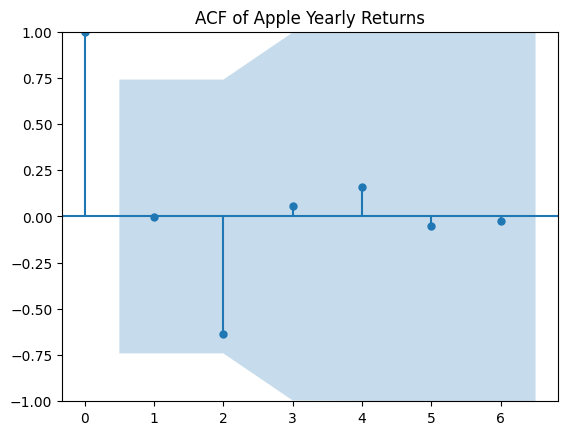

<Figure size 1000x400 with 0 Axes>

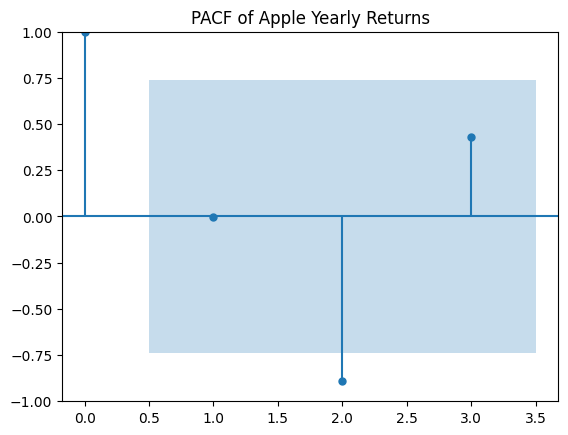

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use yearly merged dataset
ts = merged_df.copy().sort_values("year")

# Compute yearly return if not already present
if "yearly_return" not in ts.columns:
    ts["yearly_return"] = ts["close_price"].pct_change()

# Clean the series
returns = ts["yearly_return"].dropna().astype(float)

print("Number of yearly return observations:", len(returns))

# ---- ACF (use as many lags as allowed) ----
acf_lags = min(6, len(returns) - 1)

plt.figure(figsize=(10,4))
plot_acf(returns, lags=acf_lags)
plt.title("ACF of Apple Yearly Returns")
plt.show()

# ---- PACF (very small sample → cap at 3 lags) ----
pacf_lags = min(3, len(returns) - 1)

plt.figure(figsize=(10,4))
plot_pacf(returns, lags=pacf_lags, method="yw")   # safest method
plt.title("PACF of Apple Yearly Returns")
plt.show()

ACF and PACF evaluate whether a time-series variable exhibits memory or dependence on its own past values. These tools help determine whether an autoregressive model may be appropriate and whether a series has momentum, persistence, or randomness. This method was applied to Apple’s yearly stock returns (computed from the yearly-aggregated financial dataset). The returns series was cleaned, differenced using pct_change(), and analyzed using plot_acf and plot_pacf.

Augmented Dickey–Fuller Test (ADF Unit Root Test)

In [ ]:
news_q = (
    apple_news
        .groupby(apple_news.index.to_period("Q"))
        .agg({"sentiment_score": "mean"})
        .reset_index()
)

/tmp/ipython-input-2364906333.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(apple_news.index.to_period("Q"))


In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Quarterly sentiment series
sent_ts = news_q.copy()
sent_ts["quarter_end"] = sent_ts["date"].dt.to_timestamp()
sent_ts = sent_ts.set_index("quarter_end")["sentiment_score"]

# Run ADF test
adf_result = adfuller(sent_ts.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print("Critical Value (%s): %.3f" % (key, value))

ADF Statistic: -2.493476095915665
p-value: 0.11706974117365987
Critical Value (1%): -3.859
Critical Value (5%): -3.042
Critical Value (10%): -2.661


The ADF test evaluates whether a time series is stationary (fluctuates around a stable mean) or non-stationary (exhibits a trend, drift, or long-term growth pattern). Stationarity is fundamental to understanding whether shocks persist over time or dissipate. This test was applied to the quarterly average news sentiment time series, which was derived by aggregating daily sentiment into quarterly means to align with financial reporting periods. The ADF statistic and p-value were computed using adfuller().